In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
!ls -lh /content

total 61M
-rw-r--r-- 1 root root  61M Sep 20 13:05 archive.zip
drwxr-xr-x 1 root root 4.0K Sep  4 13:32 sample_data


In [4]:
import zipfile
import os

zip_path = "/content/archive.zip"
extract_path = "/content/fer2013"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
import os

dataset_path = "/content/fer2013"

print("Dataset contents:")
print(os.listdir(dataset_path))

Dataset contents:
['train', 'test']


In [6]:
train_path = "/content/fer2013/train"
test_path = "/content/fer2013/test"

print("Training classes:")
print(sorted(os.listdir(train_path)))

print("\nTesting classes:")
print(sorted(os.listdir(test_path)))

Training classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Testing classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [7]:
print("TRAINING DATA")
print("-" * 35)

total_train = 0

for emotion in sorted(os.listdir(train_path)):
    emotion_path = os.path.join(train_path, emotion)

    if os.path.isdir(emotion_path):
        count = len(os.listdir(emotion_path))
        total_train += count
        print(f"{emotion:12s}: {count}")

print("-" * 35)
print("Total training images:", total_train)


print("\nTEST DATA")
print("-" * 35)

total_test = 0

for emotion in sorted(os.listdir(test_path)):
    emotion_path = os.path.join(test_path, emotion)

    if os.path.isdir(emotion_path):
        count = len(os.listdir(emotion_path))
        total_test += count
        print(f"{emotion:12s}: {count}")

print("-" * 35)
print("Total test images:", total_test)

print("\nTotal dataset images:", total_train + total_test)

TRAINING DATA
-----------------------------------
angry       : 3995
disgust     : 436
fear        : 4097
happy       : 7215
neutral     : 4965
sad         : 4830
surprise    : 3171
-----------------------------------
Total training images: 28709

TEST DATA
-----------------------------------
angry       : 958
disgust     : 111
fear        : 1024
happy       : 1774
neutral     : 1233
sad         : 1247
surprise    : 831
-----------------------------------
Total test images: 7178

Total dataset images: 35887


File: Training_84609076.jpg
Image size: (48, 48)
Image mode: L


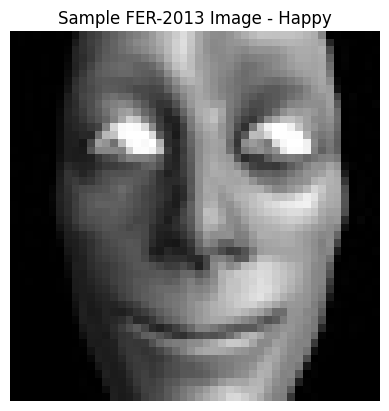

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

emotion = "happy"

folder = os.path.join(train_path, emotion)
image_name = os.listdir(folder)[0]
image_path = os.path.join(folder, image_name)

image = Image.open(image_path)

print("File:", image_name)
print("Image size:", image.size)
print("Image mode:", image.mode)

plt.imshow(image, cmap="gray")
plt.title("Sample FER-2013 Image - Happy")
plt.axis("off")
plt.show()

In [9]:
import os
import pandas as pd

train_counts = {}
test_counts = {}

for emotion in sorted(os.listdir(train_path)):
    path = os.path.join(train_path, emotion)
    if os.path.isdir(path):
        train_counts[emotion] = len(os.listdir(path))

for emotion in sorted(os.listdir(test_path)):
    path = os.path.join(test_path, emotion)
    if os.path.isdir(path):
        test_counts[emotion] = len(os.listdir(path))

distribution_df = pd.DataFrame({
    "Class": list(train_counts.keys()),
    "Train": list(train_counts.values()),
    "Test": [test_counts[c] for c in train_counts.keys()]
})

distribution_df["Total"] = (
    distribution_df["Train"] +
    distribution_df["Test"]
)

distribution_df

,Class,Train,Test,Total
0,angry,3995,958,4953
1,disgust,436,111,547
2,fear,4097,1024,5121
3,happy,7215,1774,8989
4,neutral,4965,1233,6198
5,sad,4830,1247,6077
6,surprise,3171,831,4002


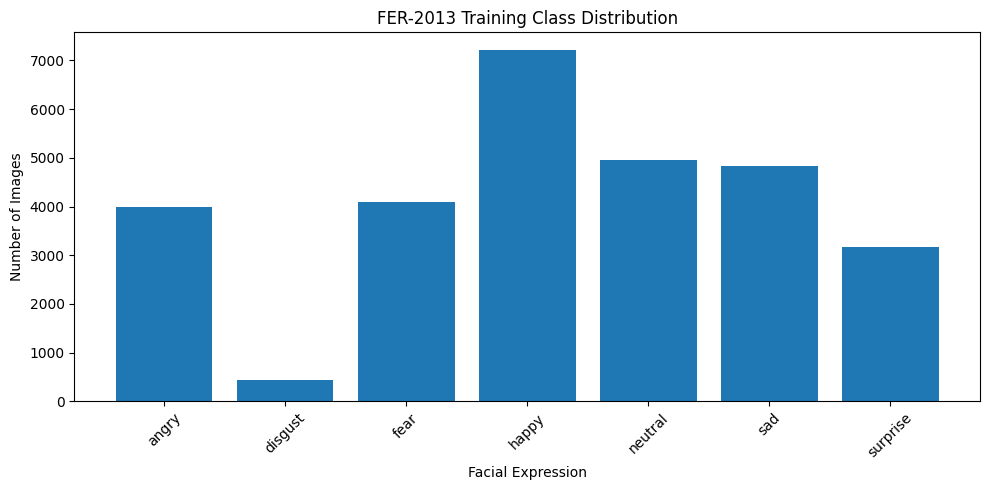

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    distribution_df["Class"],
    distribution_df["Train"]
)

plt.title("FER-2013 Training Class Distribution")
plt.xlabel("Facial Expression")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [11]:
distribution_df["Train Percentage (%)"] = (
    distribution_df["Train"]
    / distribution_df["Train"].sum()
    * 100
).round(2)

distribution_df

,Class,Train,Test,Total,Train Percentage (%)
0,angry,3995,958,4953,13.92
1,disgust,436,111,547,1.52
2,fear,4097,1024,5121,14.27
3,happy,7215,1774,8989,25.13
4,neutral,4965,1233,6198,17.29
5,sad,4830,1247,6077,16.82
6,surprise,3171,831,4002,11.05


In [12]:
most_class = distribution_df.loc[
    distribution_df["Train"].idxmax()
]

least_class = distribution_df.loc[
    distribution_df["Train"].idxmin()
]

print(
    "Most represented:",
    most_class["Class"],
    "-",
    most_class["Train"]
)

print(
    "Least represented:",
    least_class["Class"],
    "-",
    least_class["Train"]
)

Most represented: happy - 7215
Least represented: disgust - 436


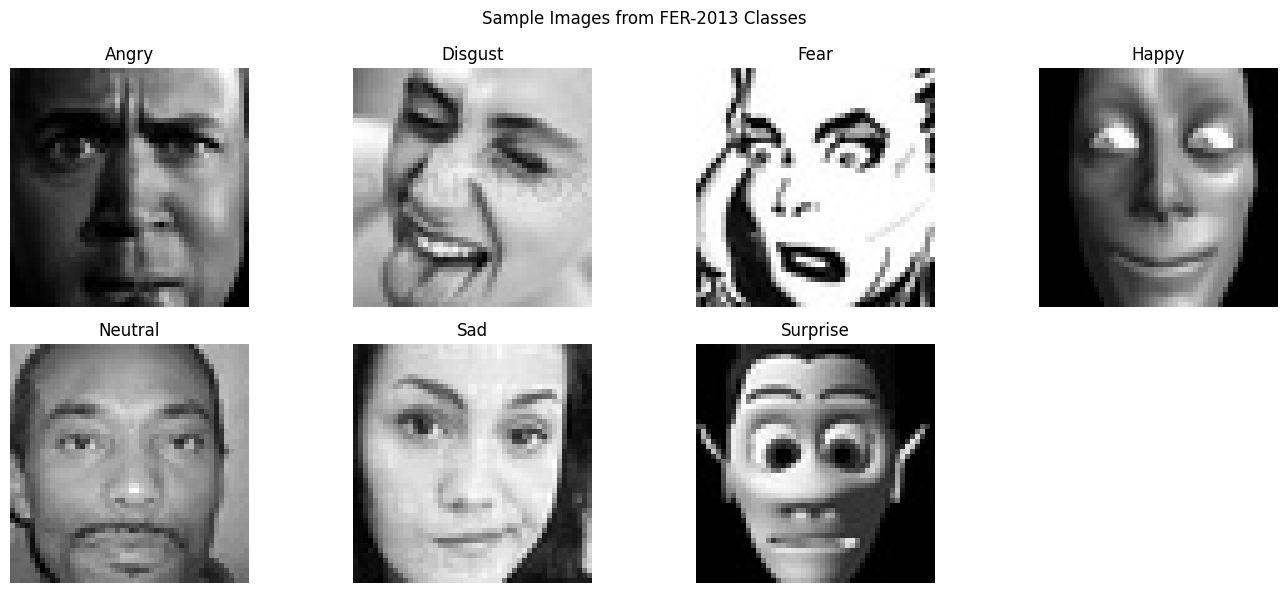

In [13]:
from PIL import Image

classes = sorted(os.listdir(train_path))

plt.figure(figsize=(14, 6))

for i, emotion in enumerate(classes):

    emotion_folder = os.path.join(train_path, emotion)

    if not os.path.isdir(emotion_folder):
        continue

    image_name = os.listdir(emotion_folder)[0]
    image_path = os.path.join(
        emotion_folder,
        image_name
    )

    image = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(emotion.capitalize())
    plt.axis("off")

plt.suptitle("Sample Images from FER-2013 Classes")
plt.tight_layout()
plt.show()

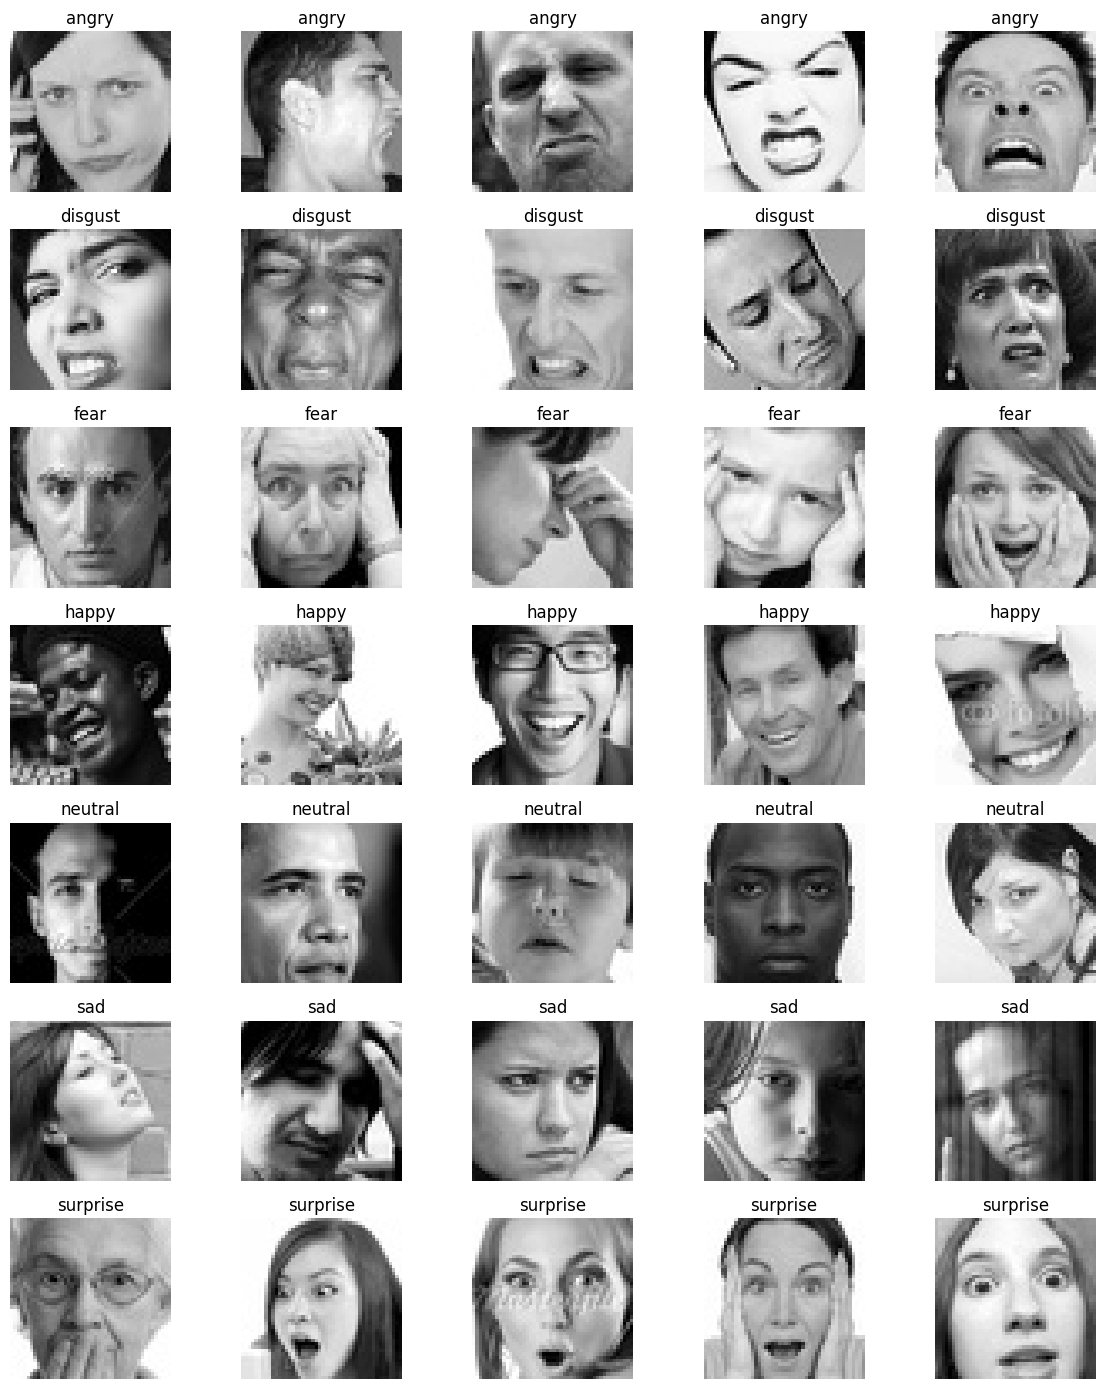

In [14]:
import random

classes = sorted([
    c for c in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, c))
])

plt.figure(figsize=(12, 14))

plot_number = 1

for emotion in classes:

    folder = os.path.join(train_path, emotion)
    images = os.listdir(folder)

    samples = random.sample(
        images,
        min(5, len(images))
    )

    for image_name in samples:

        image = Image.open(
            os.path.join(folder, image_name)
        )

        plt.subplot(
            len(classes),
            5,
            plot_number
        )

        plt.imshow(image, cmap="gray")
        plt.title(emotion)
        plt.axis("off")

        plot_number += 1

plt.tight_layout()
plt.show()

In [15]:
from collections import Counter

image_sizes = []

for emotion in classes:

    folder = os.path.join(train_path, emotion)

    for image_name in os.listdir(folder):

        image_path = os.path.join(
            folder,
            image_name
        )

        try:
            with Image.open(image_path) as img:
                image_sizes.append(img.size)
        except Exception:
            pass

size_counts = Counter(image_sizes)

print("Image dimensions:")
print(size_counts)

Image dimensions:
Counter({(48, 48): 28709})


In [16]:
corrupted_images = []

for split_path in [train_path, test_path]:

    for emotion in os.listdir(split_path):

        folder = os.path.join(
            split_path,
            emotion
        )

        if not os.path.isdir(folder):
            continue

        for image_name in os.listdir(folder):

            image_path = os.path.join(
                folder,
                image_name
            )

            try:
                with Image.open(image_path) as img:
                    img.verify()

            except Exception:
                corrupted_images.append(image_path)

print("Corrupted images:", len(corrupted_images))

Corrupted images: 0


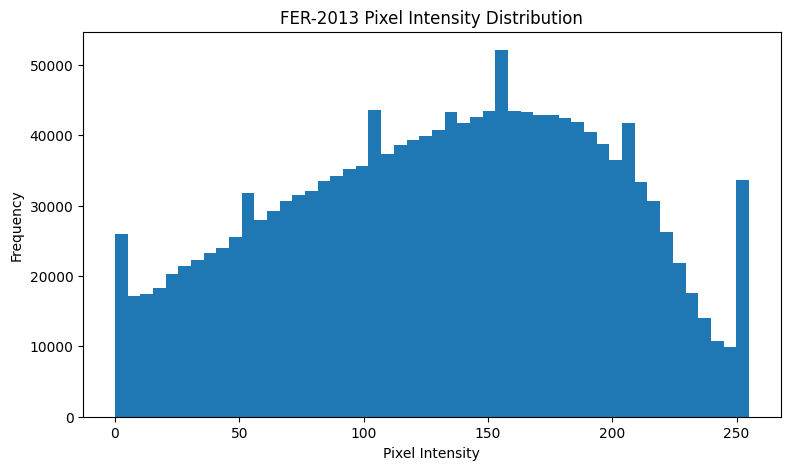

Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 131.76


In [17]:
import numpy as np
import random

pixel_values = []

for emotion in classes:

    folder = os.path.join(train_path, emotion)
    image_names = os.listdir(folder)

    samples = random.sample(
        image_names,
        min(100, len(image_names))
    )

    for image_name in samples:

        image = Image.open(
            os.path.join(folder, image_name)
        ).convert("L")

        pixels = np.array(image).flatten()
        pixel_values.extend(pixels)

plt.figure(figsize=(9, 5))

plt.hist(
    pixel_values,
    bins=50
)

plt.title("FER-2013 Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

print("Minimum pixel value:", np.min(pixel_values))
print("Maximum pixel value:", np.max(pixel_values))
print("Mean pixel value:", round(np.mean(pixel_values), 2))

## Exploratory Data Analysis Summary

- The FER-2013 dataset contains seven facial-expression classes:
  Angry, Disgust, Fear, Happy, Neutral, Sad and Surprise.
- The training and testing sets contain 28709 and 7178 images,
  respectively.
- Images have a resolution of 48 × 48 pixels.
- The images are grayscale.
- The most represented training class is happy.
- The least represented training class is disgust.
- The class distribution indicates that the dataset is imbalanced,
  with some facial-expression classes containing substantially more training samples than others.
- The dataset contains 0 corrupted/unreadable images.
- Visual inspection indicates variation in facial appearance,
  expression intensity, lighting and pose.
- Some facial-expression categories appear visually similar, which
  may make classification challenging.

In [18]:
import tensorflow as tf

SEED = 42
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Seed:", SEED)
print("Batch size:", BATCH_SIZE)
print("Image size:", IMG_SIZE)

Seed: 42
Batch size: 32
Image size: (224, 224)


In [19]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="categorical",
    shuffle=True
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.


In [20]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="categorical",
    shuffle=True
)

Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


In [21]:
validation_split=0.20
seed=42

In [22]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="categorical",
    shuffle=False
)

Found 7178 files belonging to 7 classes.


In [23]:
class_names = train_ds.class_names

print("Classes:")
print(class_names)

print("\nNumber of classes:", len(class_names))

Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Number of classes: 7


In [24]:
print("Train:", train_ds.class_names)
print("Validation:", val_ds.class_names)
print("Test:", test_ds.class_names)

assert train_ds.class_names == val_ds.class_names
assert train_ds.class_names == test_ds.class_names

print("\nClass mappings are consistent!")

Train: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Validation: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Class mappings are consistent!


In [25]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Image data type:", images.dtype)

Images shape: (32, 224, 224, 3)
Labels shape: (32, 7)
Image data type: <dtype: 'float32'>


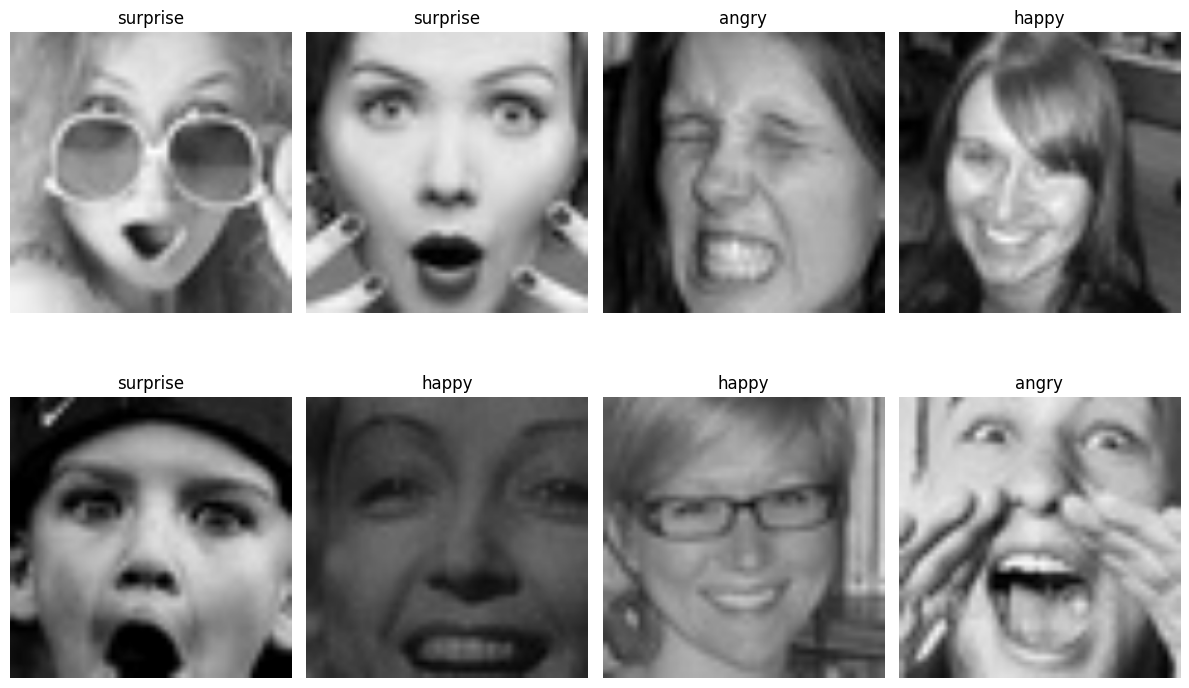

In [26]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    for i in range(8):

        plt.subplot(2, 4, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        label_index = np.argmax(labels[i].numpy())

        plt.title(class_names[label_index])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
class_names = [
    'angry',
    'disgust',
    'fear',
    'happy',
    'neutral',
    'sad',
    'surprise'
]

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Class names:", class_names)
print("Number of classes:", len(class_names))
print("Prefetch successfully applied!")

Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7
Prefetch successfully applied!


In [30]:
from tensorflow.keras.applications.resnet50 import preprocess_input

print("ResNet50 preprocessing imported successfully!")

ResNet50 preprocessing imported successfully!


In [31]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomTranslation
)

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.10),
    RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
], name="data_augmentation")

print("Data augmentation created successfully!")

Data augmentation created successfully!


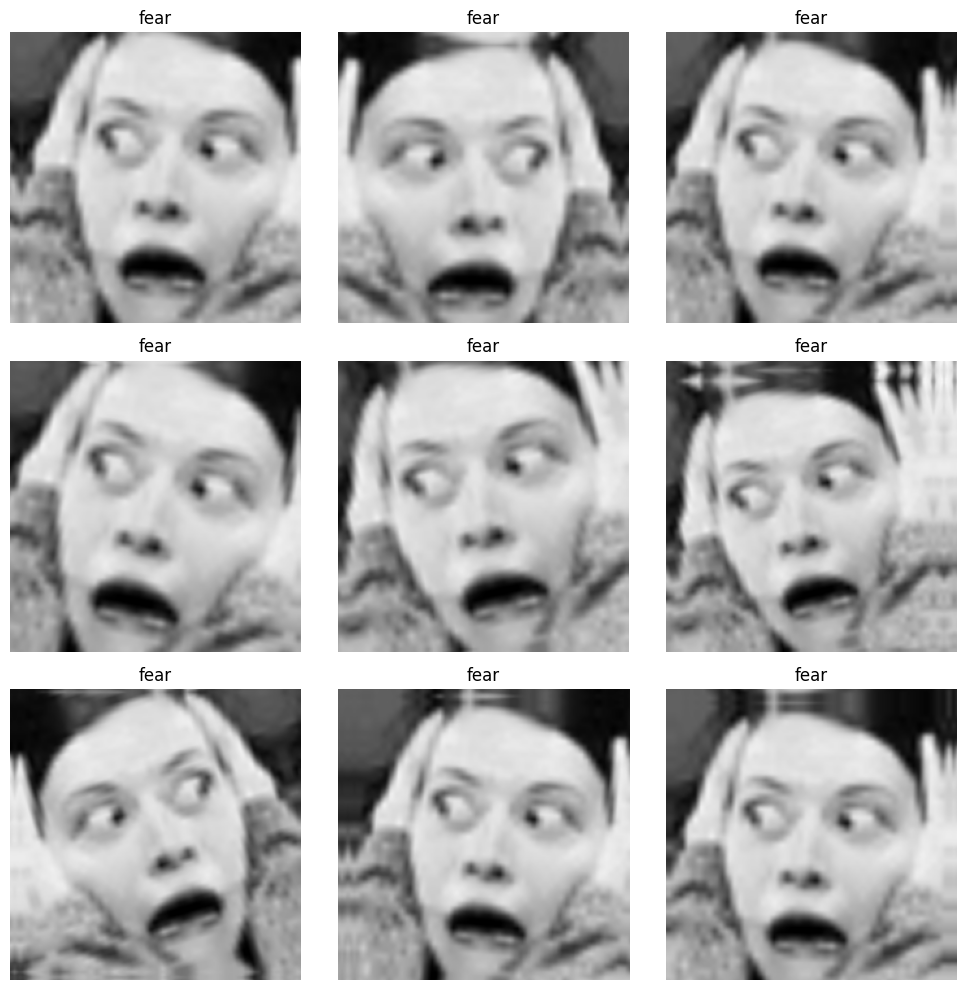

In [32]:
import matplotlib.pyplot as plt
import numpy as np

for images, labels in train_ds.take(1):

    sample_image = images[0]
    label_index = np.argmax(labels[0].numpy())

    plt.figure(figsize=(10, 10))

    for i in range(9):

        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, 0),
            training=True
        )

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            tf.cast(
                tf.clip_by_value(
                    augmented_image[0],
                    0,
                    255
                ),
                tf.uint8
            )
        )

        plt.title(class_names[label_index])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [33]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("ResNet50 loaded successfully!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
ResNet50 loaded successfully!


In [34]:
base_model.trainable = False

print("Base model trainable:", base_model.trainable)

Base model trainable: False


In [35]:
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dropout,
    Dense
)

from tensorflow.keras.models import Model

inputs = Input(
    shape=(224, 224, 3),
    name="input_image"
)

# Training augmentation
x = data_augmentation(inputs)

# ResNet50-specific preprocessing
x = preprocess_input(x)

# Pretrained ResNet50
x = base_model(
    x,
    training=False
)

# Classification head
x = GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = Dropout(
    0.5,
    name="dropout"
)(x)

outputs = Dense(
    7,
    activation="softmax",
    name="emotion_predictions"
)(x)

model = Model(
    inputs,
    outputs,
    name="FER2013_ResNet50"
)

print("Model created successfully!")

Model created successfully!


In [36]:
model.summary()

Model: "FER2013_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emotion_predictions │ (None, 7)         │     14,343 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,602,055 (90.03 MB)

 Trainable params: 14,343 (56.03 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [37]:
total_params = model.count_params()

trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in model.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in model.non_trainable_weights
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")

Total parameters: 23,602,055
Trainable parameters: 14,343
Non-trainable parameters: 23,587,712


In [38]:
from tensorflow.keras.optimizers import Adam

INITIAL_LEARNING_RATE = 0.001

model.compile(
    optimizer=Adam(
        learning_rate=INITIAL_LEARNING_RATE
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [39]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

checkpoint_path = "/content/best_resnet50_stage1.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured successfully!")

Callbacks configured successfully!


In [40]:
print("Base model trainable:", base_model.trainable)

Base model trainable: False


In [41]:
EPOCHS_STAGE1 = 20

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks
)

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.3256 - loss: 1.9376
Epoch 1: val_loss improved from None to 1.39763, saving model to /content/best_resnet50_stage1.keras

Epoch 1: finished saving model to /content/best_resnet50_stage1.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 141s 182ms/step - accuracy: 0.3724 - loss: 1.7334 - val_accuracy: 0.4818 - val_loss: 1.3976 - learning_rate: 0.0010
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.4270 - loss: 1.5459
Epoch 2: val_loss improved from 1.39763 to 1.39003, saving model to /content/best_resnet50_stage1.keras

Epoch 2: finished saving model to /content/best_resnet50_stage1.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 134s 186ms/step - accuracy: 0.4314 - loss: 1.5339 - val_accuracy: 0.4839 - val_loss: 1.3900 - learning_rate: 0.0010
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.4341 - loss: 1.5199
Epoch 3: val_loss improved from 1.39003 to 1.36249, saving model to /content/best_resnet50_stage1.k

In [42]:
best_train_acc = max(history_stage1.history["accuracy"])
best_val_acc = max(history_stage1.history["val_accuracy"])

lowest_train_loss = min(history_stage1.history["loss"])
lowest_val_loss = min(history_stage1.history["val_loss"])

print(f"Best Training Accuracy:   {best_train_acc:.4f}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

print(f"\nLowest Training Loss:   {lowest_train_loss:.4f}")
print(f"Lowest Validation Loss: {lowest_val_loss:.4f}")

print(
    "\nEpochs completed:",
    len(history_stage1.history["loss"])
)

Best Training Accuracy:   0.4860
Best Validation Accuracy: 0.5285

Lowest Training Loss:   1.3647
Lowest Validation Loss: 1.2616

Epochs completed: 20


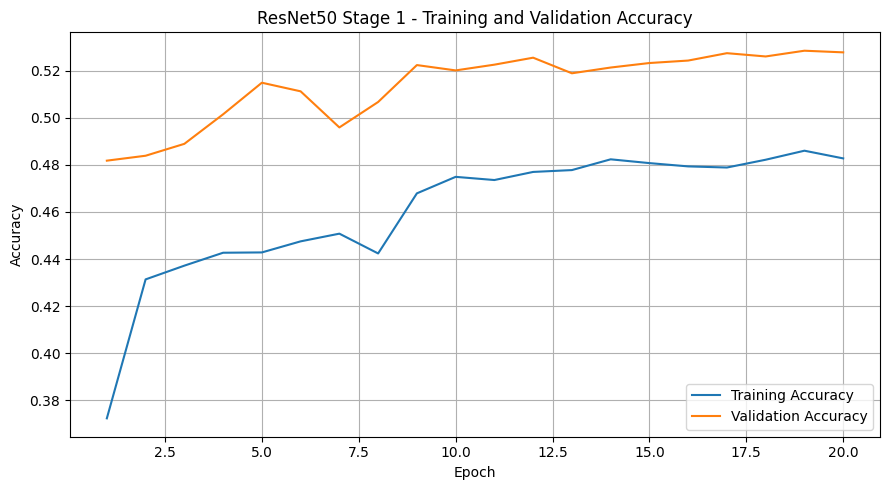

In [43]:
import matplotlib.pyplot as plt

epochs = range(
    1,
    len(history_stage1.history["accuracy"]) + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    history_stage1.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_stage1.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ResNet50 Stage 1 - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

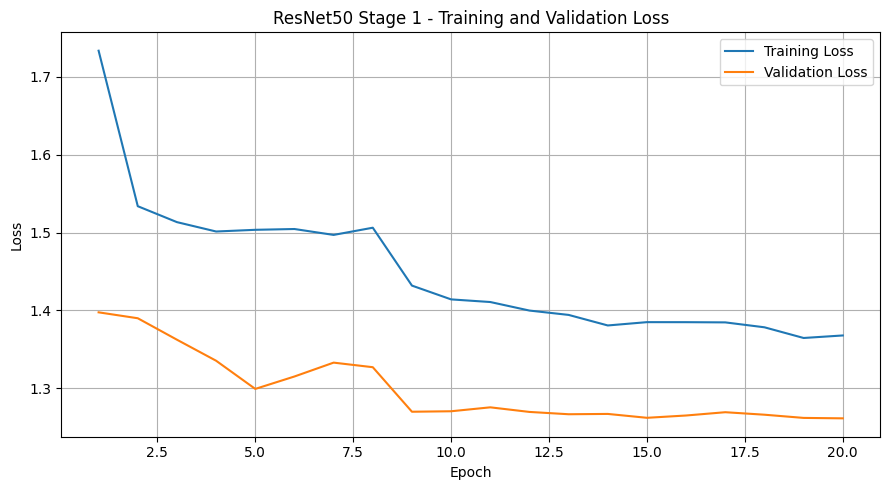

In [44]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    history_stage1.history["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_stage1.history["val_loss"],
    label="Validation Loss"
)

plt.title("ResNet50 Stage 1 - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [45]:
import numpy as np

best_epoch = np.argmin(
    history_stage1.history["val_loss"]
) + 1

best_val_loss = min(
    history_stage1.history["val_loss"]
)

val_acc_at_best_epoch = history_stage1.history[
    "val_accuracy"
][best_epoch - 1]

print("Best epoch:", best_epoch)
print(f"Best validation loss: {best_val_loss:.4f}")
print(
    f"Validation accuracy at best epoch: "
    f"{val_acc_at_best_epoch:.4f}"
)

Best epoch: 20
Best validation loss: 1.2616
Validation accuracy at best epoch: 0.5278


In [46]:
monitor="val_loss"

In [47]:
import pandas as pd

history_stage1_df = pd.DataFrame(
    history_stage1.history
)

history_stage1_df.index += 1
history_stage1_df.index.name = "epoch"

history_stage1_df.to_csv(
    "/content/resnet50_stage1_history.csv"
)

history_stage1_df.tail()

,accuracy,loss,val_accuracy,val_loss,learning_rate
epoch,,,,,
16,0.479363,1.384999,0.524299,1.265210,0.00020
17,0.478884,1.384730,0.527434,1.269425,0.00020
18,0.482193,1.378422,0.526041,1.266224,0.00020
19,0.486024,1.364708,0.528479,1.262118,0.00004
20,0.482759,1.367944,0.527783,1.261564,0.00004


In [48]:
from tensorflow.keras.models import load_model

model = load_model("/content/best_resnet50_stage1.keras")

print("Best Stage 1 model loaded!")

Best Stage 1 model loaded!


In [49]:
base_model = model.get_layer("resnet50")

print("Base model:", base_model.name)
print("Number of ResNet50 layers:", len(base_model.layers))

Base model: resnet50
Number of ResNet50 layers: 175


In [50]:
base_model.trainable = True

In [51]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

In [52]:
from tensorflow.keras.layers import BatchNormalization

for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

In [53]:
trainable_base_layers = sum(
    1 for layer in base_model.layers
    if layer.trainable
)

print("Total ResNet50 layers:", len(base_model.layers))
print("Trainable ResNet50 layers:", trainable_base_layers)

Total ResNet50 layers: 175
Trainable ResNet50 layers: 21


In [54]:
from tensorflow.keras.optimizers import Adam

FINE_TUNE_LR = 1e-5

model.compile(
    optimizer=Adam(learning_rate=FINE_TUNE_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled!")
print("Learning rate:", FINE_TUNE_LR)

Fine-tuning model compiled!
Learning rate: 1e-05


In [55]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

fine_tune_checkpoint = "/content/best_resnet50_finetuned.keras"

fine_tune_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        fine_tune_checkpoint,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [56]:
FINE_TUNE_EPOCHS = 15

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks
)

Epoch 1/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.5071 - loss: 1.3101
Epoch 1: val_loss improved from None to 1.16386, saving model to /content/best_resnet50_finetuned.keras

Epoch 1: finished saving model to /content/best_resnet50_finetuned.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 179s 237ms/step - accuracy: 0.5202 - loss: 1.2759 - val_accuracy: 0.5553 - val_loss: 1.1639 - learning_rate: 1.0000e-05
Epoch 2/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.5585 - loss: 1.1866
Epoch 2: val_loss improved from 1.16386 to 1.12481, saving model to /content/best_resnet50_finetuned.keras

Epoch 2: finished saving model to /content/best_resnet50_finetuned.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 167s 233ms/step - accuracy: 0.5632 - loss: 1.1689 - val_accuracy: 0.5804 - val_loss: 1.1248 - learning_rate: 1.0000e-05
Epoch 3/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.5781 - loss: 1.1225
Epoch 3: val_loss improved from 1.12481 to 1.09040, saving model to /content/be

In [57]:
best_ft_train_acc = max(
    history_finetune.history["accuracy"]
)

best_ft_val_acc = max(
    history_finetune.history["val_accuracy"]
)

best_ft_val_loss = min(
    history_finetune.history["val_loss"]
)

print(
    "Epochs completed:",
    len(history_finetune.history["loss"])
)

print(
    f"Best Fine-Tuning Training Accuracy: "
    f"{best_ft_train_acc:.4f}"
)

print(
    f"Best Fine-Tuning Validation Accuracy: "
    f"{best_ft_val_acc:.4f}"
)

print(
    f"Best Fine-Tuning Validation Loss: "
    f"{best_ft_val_loss:.4f}"
)

Epochs completed: 13
Best Fine-Tuning Training Accuracy: 0.7200
Best Fine-Tuning Validation Accuracy: 0.6447
Best Fine-Tuning Validation Loss: 1.0094


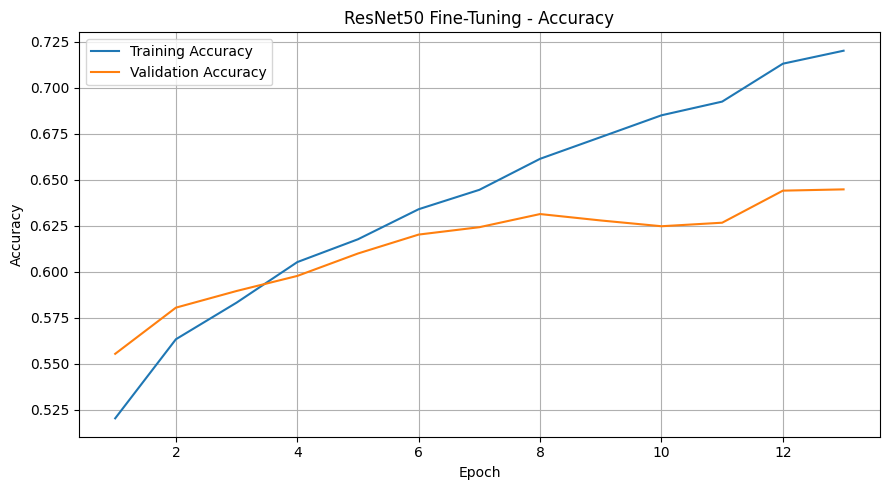

In [58]:
import matplotlib.pyplot as plt

ft_epochs = range(
    1,
    len(history_finetune.history["accuracy"]) + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    ft_epochs,
    history_finetune.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    ft_epochs,
    history_finetune.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ResNet50 Fine-Tuning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

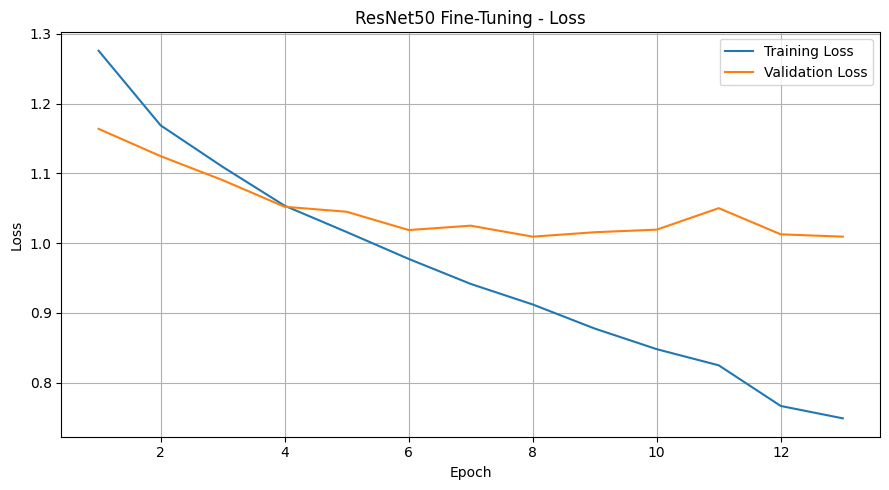

In [59]:
plt.figure(figsize=(9, 5))

plt.plot(
    ft_epochs,
    history_finetune.history["loss"],
    label="Training Loss"
)

plt.plot(
    ft_epochs,
    history_finetune.history["val_loss"],
    label="Validation Loss"
)

plt.title("ResNet50 Fine-Tuning - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [60]:
import pandas as pd

comparison = pd.DataFrame({
    "Stage": [
        "Frozen ResNet50",
        "Fine-Tuned ResNet50"
    ],
    "Best Train Accuracy": [
        max(history_stage1.history["accuracy"]),
        max(history_finetune.history["accuracy"])
    ],
    "Best Validation Accuracy": [
        max(history_stage1.history["val_accuracy"]),
        max(history_finetune.history["val_accuracy"])
    ],
    "Best Validation Loss": [
        min(history_stage1.history["val_loss"]),
        min(history_finetune.history["val_loss"])
    ]
})

comparison

,Stage,Best Train Accuracy,Best Validation Accuracy,Best Validation Loss
0,Frozen ResNet50,0.486024,0.528479,1.261564
1,Fine-Tuned ResNet50,0.720002,0.644661,1.009379


In [61]:
comparison.to_csv(
    "/content/resnet50_stage_comparison.csv",
    index=False
)

In [62]:
history_finetune_df = pd.DataFrame(
    history_finetune.history
)

history_finetune_df.index += 1
history_finetune_df.index.name = "epoch"

history_finetune_df.to_csv(
    "/content/resnet50_finetune_history.csv"
)

print("Fine-tuning history saved!")

Fine-tuning history saved!


In [63]:
from tensorflow.keras.models import load_model

final_model = load_model(
    "/content/best_resnet50_finetuned.keras"
)

print("Best fine-tuned ResNet50 loaded successfully!")

Best fine-tuned ResNet50 loaded successfully!


In [64]:
test_loss, test_accuracy = final_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 151ms/step - accuracy: 0.6291 - loss: 1.0094
Test Loss:     1.0094
Test Accuracy: 0.6291
Test Accuracy: 62.91%


In [65]:
import numpy as np

y_true = []
y_prob = []

for images, labels in test_ds:

    predictions = final_model.predict(
        images,
        verbose=0
    )

    y_prob.extend(predictions)

    y_true.extend(
        np.argmax(labels.numpy(), axis=1)
    )

y_true = np.array(y_true)
y_prob = np.array(y_prob)

y_pred = np.argmax(
    y_prob,
    axis=1
)

print("Number of test samples:", len(y_true))
print("Predictions:", len(y_pred))
print("Probability shape:", y_prob.shape)

Number of test samples: 7178
Predictions: 7178
Probability shape: (7178, 7)


In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("===== RESNET50 FINAL TEST RESULTS =====")

print(f"Accuracy:           {accuracy:.4f}")
print(f"Macro Precision:    {macro_precision:.4f}")
print(f"Macro Recall:       {macro_recall:.4f}")
print(f"Macro F1:           {macro_f1:.4f}")

print()

print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall:    {weighted_recall:.4f}")
print(f"Weighted F1:        {weighted_f1:.4f}")

===== RESNET50 FINAL TEST RESULTS =====
Accuracy:           0.6291
Macro Precision:    0.6112
Macro Recall:       0.5680
Macro F1:           0.5766

Weighted Precision: 0.6205
Weighted Recall:    0.6291
Weighted F1:        0.6177


In [67]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

       angry     0.4890    0.5783    0.5299       958
     disgust     0.6250    0.3153    0.4192       111
        fear     0.5327    0.3184    0.3985      1024
       happy     0.7768    0.9002    0.8339      1774
     neutral     0.5725    0.6529    0.6101      1233
         sad     0.5308    0.4635    0.4949      1247
    surprise     0.7518    0.7473    0.7495       831

    accuracy                         0.6291      7178
   macro avg     0.6112    0.5680    0.5766      7178
weighted avg     0.6205    0.6291    0.6177      7178



In [68]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

import pandas as pd

report_df = pd.DataFrame(
    report_dict
).transpose()

report_df.to_csv(
    "/content/resnet50_classification_report.csv"
)

report_df

,precision,recall,f1-score,support
angry,0.488967,0.578288,0.529890,958.000000
disgust,0.625000,0.315315,0.419162,111.000000
fear,0.532680,0.318359,0.398533,1024.000000
happy,0.776751,0.900225,0.833943,1774.000000
neutral,0.572546,0.652879,0.610080,1233.000000
sad,0.530762,0.463512,0.494863,1247.000000
surprise,0.751816,0.747292,0.749547,831.000000
accuracy,0.629145,0.629145,0.629145,0.629145
macro avg,0.611217,0.567982,0.576574,7178.000000
weighted avg,0.620479,0.629145,0.617703,7178.000000


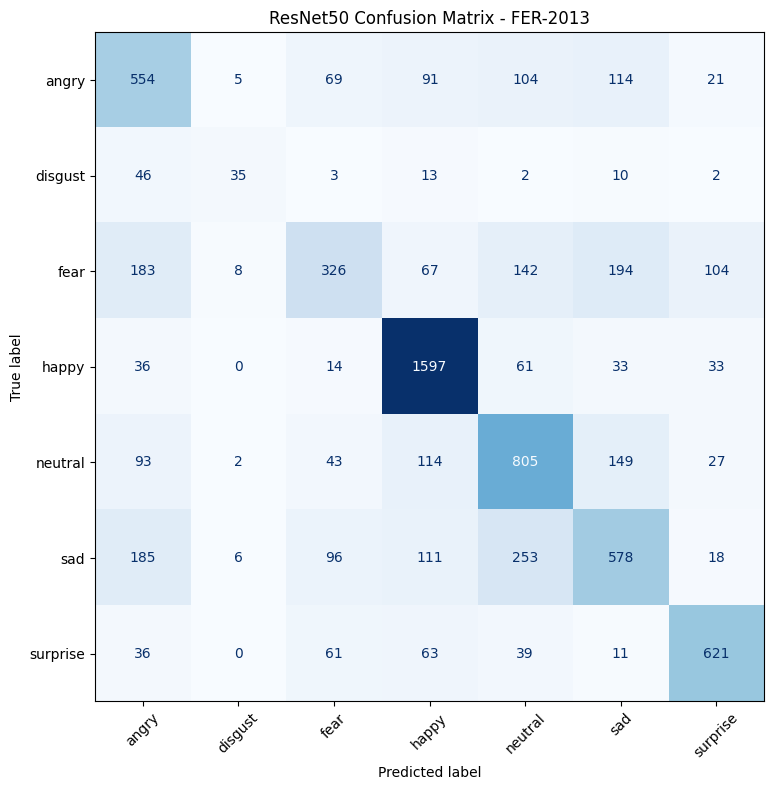

In [69]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

fig, ax = plt.subplots(
    figsize=(9, 8)
)

display = __import__(
    "sklearn.metrics",
    fromlist=["ConfusionMatrixDisplay"]
).ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)

plt.title(
    "ResNet50 Confusion Matrix - FER-2013"
)

plt.tight_layout()

plt.savefig(
    "/content/resnet50_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

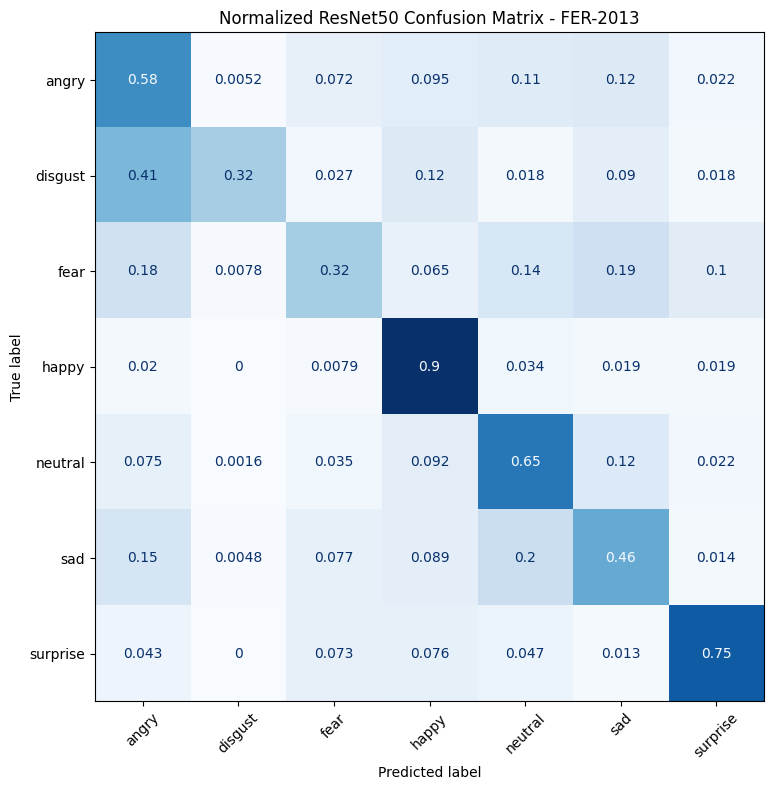

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(
    figsize=(9, 8)
)

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=class_names,
    normalize="true",
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title(
    "Normalized ResNet50 Confusion Matrix - FER-2013"
)

plt.tight_layout()

plt.savefig(
    "/content/resnet50_normalized_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [72]:
from sklearn.metrics import roc_auc_score
from tensorflow.keras.utils import to_categorical

y_true_onehot = to_categorical(
    y_true,
    num_classes=len(class_names)
)

macro_auc = roc_auc_score(
    y_true_onehot,
    y_prob,
    multi_class="ovr",
    average="macro"
)

weighted_auc = roc_auc_score(
    y_true_onehot,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print(
    f"Macro ROC-AUC (OvR): {macro_auc:.4f}"
)

print(
    f"Weighted ROC-AUC (OvR): {weighted_auc:.4f}"
)

Macro ROC-AUC (OvR): 0.9006
Weighted ROC-AUC (OvR): 0.8968


In [73]:
final_results = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Macro ROC-AUC",
        "Weighted ROC-AUC"
    ],

    "Value": [
        accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_precision,
        weighted_recall,
        weighted_f1,
        macro_auc,
        weighted_auc
    ]
})

final_results["Value"] = (
    final_results["Value"].round(4)
)

final_results

,Metric,Value
0,Test Accuracy,0.6291
1,Macro Precision,0.6112
2,Macro Recall,0.5680
3,Macro F1,0.5766
4,Weighted Precision,0.6205
5,Weighted Recall,0.6291
6,Weighted F1,0.6177
7,Macro ROC-AUC,0.9006
8,Weighted ROC-AUC,0.8968


In [74]:
final_results.to_csv(
    "/content/resnet50_final_results.csv",
    index=False
)

print("Final results saved!")

Final results saved!


In [75]:
final_model.save(
    "/content/resnet50_fer2013_final.keras"
)

print("Final ResNet50 model saved!")

Final ResNet50 model saved!


## ResNet50 Final Experimental Setup

- Dataset: FER-2013
- Task: Multiclass facial-expression classification
- Number of classes: 7
- Architecture: ResNet50
- Pretrained weights: ImageNet
- Transfer learning: Yes
- Input size: 224 × 224 × 3
- Original image size: 48 × 48 grayscale
- Batch size: 32
- Optimizer: Adam
- Initial learning rate: 0.001
- Fine-tuning learning rate: 0.00001
- Loss function: Categorical Crossentropy
- Data augmentation: Horizontal flip, small rotation,
  zoom and translation
- Initial training: Frozen ResNet50 backbone
- Fine-tuning: Later ResNet50 layers unfrozen
- Early stopping: Used
- Learning-rate reduction: Used
- Best-model checkpointing: Used

## Final Test Results

- Test Accuracy: 0.6291
- Macro Precision: 0.6112
- Macro Recall: 0.5680
- Macro F1-score: 0.5766
- Weighted Precision: 0.6205
- Weighted Recall: 0.6291
- Weighted F1-score: 0.6177
- Macro ROC-AUC: 0.9006
- Weighted ROC-AUC: 0.8968

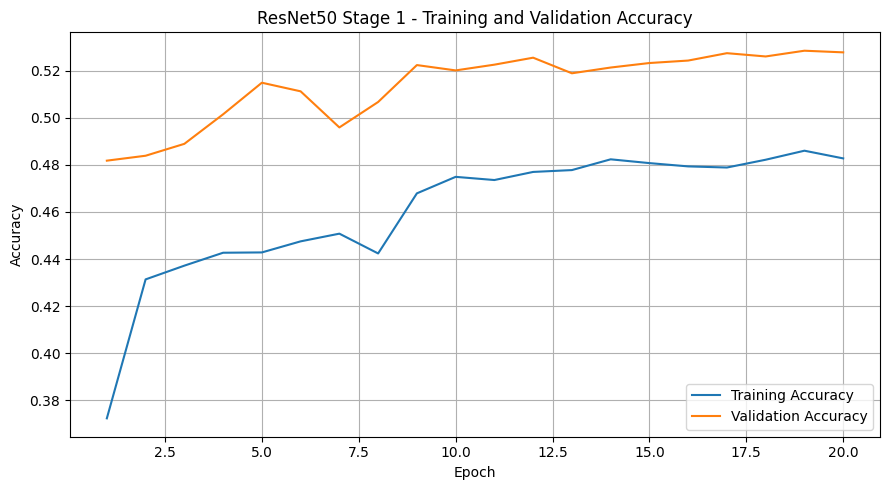

Saved: resnet50_stage1_accuracy.png


In [76]:
import matplotlib.pyplot as plt

epochs_stage1 = range(
    1,
    len(history_stage1.history["accuracy"]) + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs_stage1,
    history_stage1.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs_stage1,
    history_stage1.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ResNet50 Stage 1 - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

# SAVE FIRST
plt.savefig(
    "/content/resnet50_stage1_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

# THEN DISPLAY
plt.show()

print("Saved: resnet50_stage1_accuracy.png")

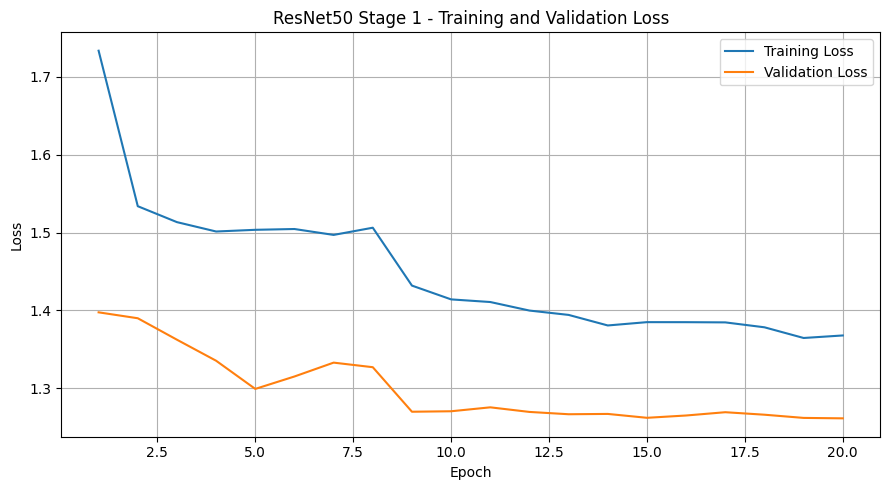

Saved: resnet50_stage1_loss.png


In [77]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs_stage1,
    history_stage1.history["loss"],
    label="Training Loss"
)

plt.plot(
    epochs_stage1,
    history_stage1.history["val_loss"],
    label="Validation Loss"
)

plt.title("ResNet50 Stage 1 - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "/content/resnet50_stage1_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: resnet50_stage1_loss.png")

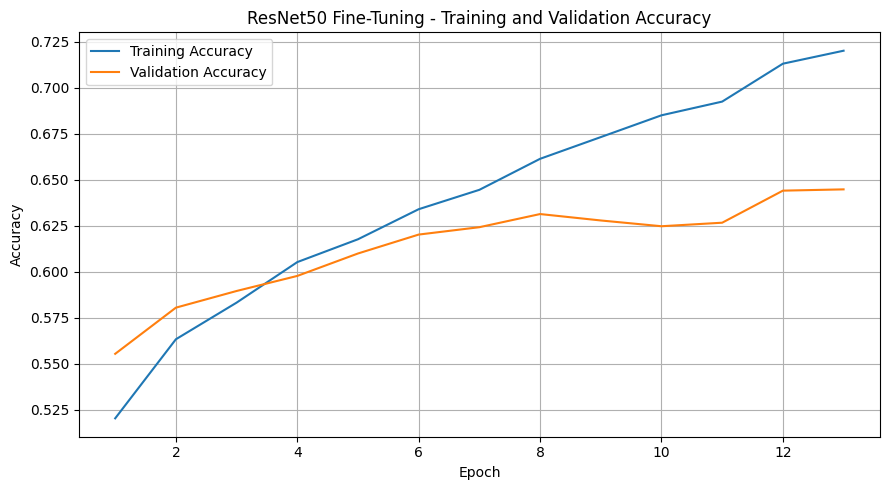

Saved: resnet50_finetune_accuracy.png


In [78]:
epochs_finetune = range(
    1,
    len(history_finetune.history["accuracy"]) + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs_finetune,
    history_finetune.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs_finetune,
    history_finetune.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ResNet50 Fine-Tuning - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "/content/resnet50_finetune_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: resnet50_finetune_accuracy.png")

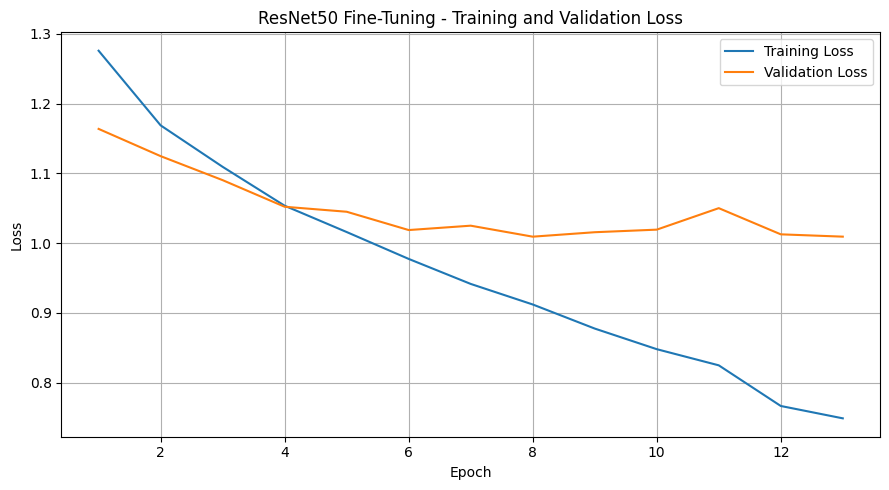

Saved: resnet50_finetune_loss.png


In [79]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs_finetune,
    history_finetune.history["loss"],
    label="Training Loss"
)

plt.plot(
    epochs_finetune,
    history_finetune.history["val_loss"],
    label="Validation Loss"
)

plt.title("ResNet50 Fine-Tuning - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "/content/resnet50_finetune_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: resnet50_finetune_loss.png")

In [80]:
import os

graph_files = [
    "/content/resnet50_stage1_accuracy.png",
    "/content/resnet50_stage1_loss.png",
    "/content/resnet50_finetune_accuracy.png",
    "/content/resnet50_finetune_loss.png"
]

for file in graph_files:
    print(
        os.path.basename(file),
        "✅ Saved" if os.path.exists(file) else "❌ Missing"
    )

resnet50_stage1_accuracy.png ✅ Saved
resnet50_stage1_loss.png ✅ Saved
resnet50_finetune_accuracy.png ✅ Saved
resnet50_finetune_loss.png ✅ Saved
